In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from scipy.io import loadmat
from scipy.io import savemat
import os
from metpy.calc import saturation_mixing_ratio
from metpy.units import units
from newcasenum import newcasenum
from newlab import newlab
from metpy.calc import static_stability
from metpy.calc import moist_lapse
from metpy.calc import potential_temperature
from metpy.calc import virtual_temperature
from metpy.calc import surface_based_cape_cin,dewpoint_from_relative_humidity
from metpy.units import units
import xarray as xr

In [2]:
def pickcases(val):
    casenums = np.array(['f299rd2','f299rx1','f299rx3d2', 'f299rx2', 'f299rx3', 'f302rd2','fixedn1', 'f302rx3d2b',
             'fixedn1x2', 'f302rx3', 'f303rd2', 'f303r1', 'f303rx3d2','f303rx2','f303rx3',
             'f305rd2', 'fixedn1p3', 'f305rx3d2', 'f305rx2','f305rx3'])
    indssts = np.array([1,1,1, 1, 1, 2,2, 2, 2, 2, 3,3,3, 3, 3, 4,4, 4, 4, 4])
    indranges = np.array([1,2,3, 4, 5, 1,2, 3, 4, 5, 1, 2, 3,4,5, 1, 2, 3, 4,5])
    ssts = np.array(['299', '302', '303.5','305'])
    ranges = np.array(['2.5','5','7.5','10','15'])
    if val in ssts:
        ind = np.nonzero(ssts==val)[0][0]+1
        subcases = casenums[indssts==ind]
    elif val in ranges:
        ind = np.nonzero(ranges==val)[0][0]+1
        subcases = casenums[indranges==ind]
        
    return subcases
def resize(test,newsize):
    nx = newsize[0]
    ny = newsize[1]
    oldsize = np.shape(test)
    ox = oldsize[0]
    oy = oldsize[1]
    nd = len(oldsize)
    newtest = np.zeros(newsize)
    if nd !=len(newsize):
        print('Number of dimensions must be the same.')
        quit()
    if nx != ox:
        xiold = np.linspace(0,1,ox)
        xinew = np.linspace(0,1,nx)
        for j in range(0,oy):
            newtest[:,j] = np.interp(xinew,xiold,test[:,j])
    if ny != oy:
        yiold = np.linspace(0,1,oy)
        yinew = np.linspace(0,1,ny)
        for i in range(0,ox):
            newtest[i,:] = np.interp(yinew,yiold,test[i,0:oy])
    return newtest
def gradsmap():
    # Define the colormap matrix
    gradsmap2 = np.array([
        [10, 50, 120],
        [15, 75, 165],
        [30, 110, 200],
        [60, 160, 240],
        [80, 180, 250],
        [130, 210, 255],
        [160, 240, 255],
        [200, 250, 255],
        [230, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        [255, 250, 220],
        [255, 232, 120],
        [255, 192, 60],
        [255, 160, 0],
        [255, 96, 0],
        [255, 50, 0],
        [225, 20, 0],
        [192, 0, 0],
        [165, 0, 0]
    ]) / 255.0
    
    # Create a colormap from the array
    cmap = mcolors.ListedColormap(gradsmap2)
    
    return cmap
def gradsmapn(n):
    # Define the colormap matrix
    gradsmap2 = np.array([
        [10, 50, 120],
        [15, 75, 165],
        [30, 110, 200],
        [60, 160, 240],
        [80, 180, 250],
        [130, 210, 255],
        [160, 240, 255],
        [200, 250, 255],
        [230, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        [255, 250, 220],
        [255, 232, 120],
        [255, 192, 60],
        [255, 160, 0],
        [255, 96, 0],
        [255, 50, 0],
        [225, 20, 0],
        [192, 0, 0],
        [165, 0, 0]
    ]) / 255.0
    gradsmap2 = resize(gradsmap2,n)

    # Create a colormap from the array
    cmap = mcolors.ListedColormap(gradsmap2)
    
    return cmap
def gradsmapf():
    # Define the colormap matrix
    gradsmap2 = np.array([
        [10, 50, 120],
        [15, 75, 165],
        [30, 110, 200],
        [60, 160, 240],
        [80, 180, 250],
        [130, 210, 255],
        [160, 240, 255],
        [200, 250, 255],
        [230, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        [255, 250, 220],
        [255, 232, 120],
        [255, 192, 60],
        [255, 160, 0],
        [255, 96, 0],
        [255, 50, 0],
        [225, 20, 0],
        [192, 0, 0],
        [165, 0, 0]
    ]) / 255.0
    # Create a colormap from the array
    cmap = mcolors.ListedColormap(np.flipud(gradsmap2))
    
    return cmap

def gradsmapfn(n):
    # Define the colormap matrix
    gradsmap2 = np.array([
        [10, 50, 120],
        [15, 75, 165],
        [30, 110, 200],
        [60, 160, 240],
        [80, 180, 250],
        [130, 210, 255],
        [160, 240, 255],
        [200, 250, 255],
        [230, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        [255, 250, 220],
        [255, 232, 120],
        [255, 192, 60],
        [255, 160, 0],
        [255, 96, 0],
        [255, 50, 0],
        [225, 20, 0],
        [192, 0, 0],
        [165, 0, 0]
    ]) / 255.0
    gradsmap2 = resize(gradsmap2,n)

    # Create a colormap from the array
    cmap = mcolors.ListedColormap(np.flipud(gradsmap2))
    
    return cmap
def gradsmap0():
    # Define the colormap matrix
    gradsmap2 = np.array([
        [255, 255, 255],
        [255, 250, 220],
        [255, 232, 120],
        [255, 192, 60],
        [255, 160, 0],
        [255, 96, 0],
        [255, 50, 0],
        [225, 20, 0],
        [192, 0, 0],
        [165, 0, 0]
    ]) / 255.0  # Normalize to [0, 1] range
    
    # Create a colormap from the array
    cmap = mcolors.ListedColormap(gradsmap2)
    
    return cmap
def gradsmap0n(n):
    # Define the colormap matrix
    gradsmap2 = np.array([
        [255, 255, 255],
        [255, 250, 220],
        [255, 232, 120],
        [255, 192, 60],
        [255, 160, 0],
        [255, 96, 0],
        [255, 50, 0],
        [225, 20, 0],
        [192, 0, 0],
        [165, 0, 0]
    ]) / 255.0  # Normalize to [0, 1] range
    gradsmap2 = resize(gradsmap2,n)
    # Create a colormap from the array
    cmap = mcolors.ListedColormap(gradsmap2)
    
    return cmap

def readnetcdf(ccase,cvar):
    path = '/home/disk/eos7/bdygert/aquafv/output/'
    flnm = path + ccase+'/history/'+ccase+'months.nc'
    data = xr.open_dataset(flnm,decode_times=False)
    pstuff = data[cvar].to_numpy()
    #p = data['pfull']
    
    return pstuff
def readstf(ccase,cvar):
    path = '/home/disk/eos8/bdygert/code/compredo/'
    flnm = path + ccase+cvar+'2dcrh.mat'
    data = loadmat(flnm)
    pstuff = data['stf']
    #p = data['pfull']
    
    return pstuff

/tmp/ipykernel_3443573/2537507725.py:334: RuntimeWarning: Mean of empty slice
  stfm = np.nanmean(stf, axis=2)
/tmp/ipykernel_3443573/2537507725.py:334: RuntimeWarning: Mean of empty slice
  stfm = np.nanmean(stf, axis=2)
/tmp/ipykernel_3443573/2537507725.py:334: RuntimeWarning: Mean of empty slice
  stfm = np.nanmean(stf, axis=2)
/tmp/ipykernel_3443573/2537507725.py:334: RuntimeWarning: Mean of empty slice
  stfm = np.nanmean(stf, axis=2)
/tmp/ipykernel_3443573/2537507725.py:334: RuntimeWarning: Mean of empty slice
  stfm = np.nanmean(stf, axis=2)
/tmp/ipykernel_3443573/2537507725.py:334: RuntimeWarning: Mean of empty slice
  stfm = np.nanmean(stf, axis=2)
/tmp/ipykernel_3443573/2537507725.py:334: RuntimeWarning: Mean of empty slice
  stfm = np.nanmean(stf, axis=2)
/tmp/ipykernel_3443573/2537507725.py:334: RuntimeWarning: Mean of empty slice
  stfm = np.nanmean(stf, axis=2)
/tmp/ipykernel_3443573/2537507725.py:334: RuntimeWarning: Mean of empty slice
  stfm = np.nanmean(stf, axis=2)
/

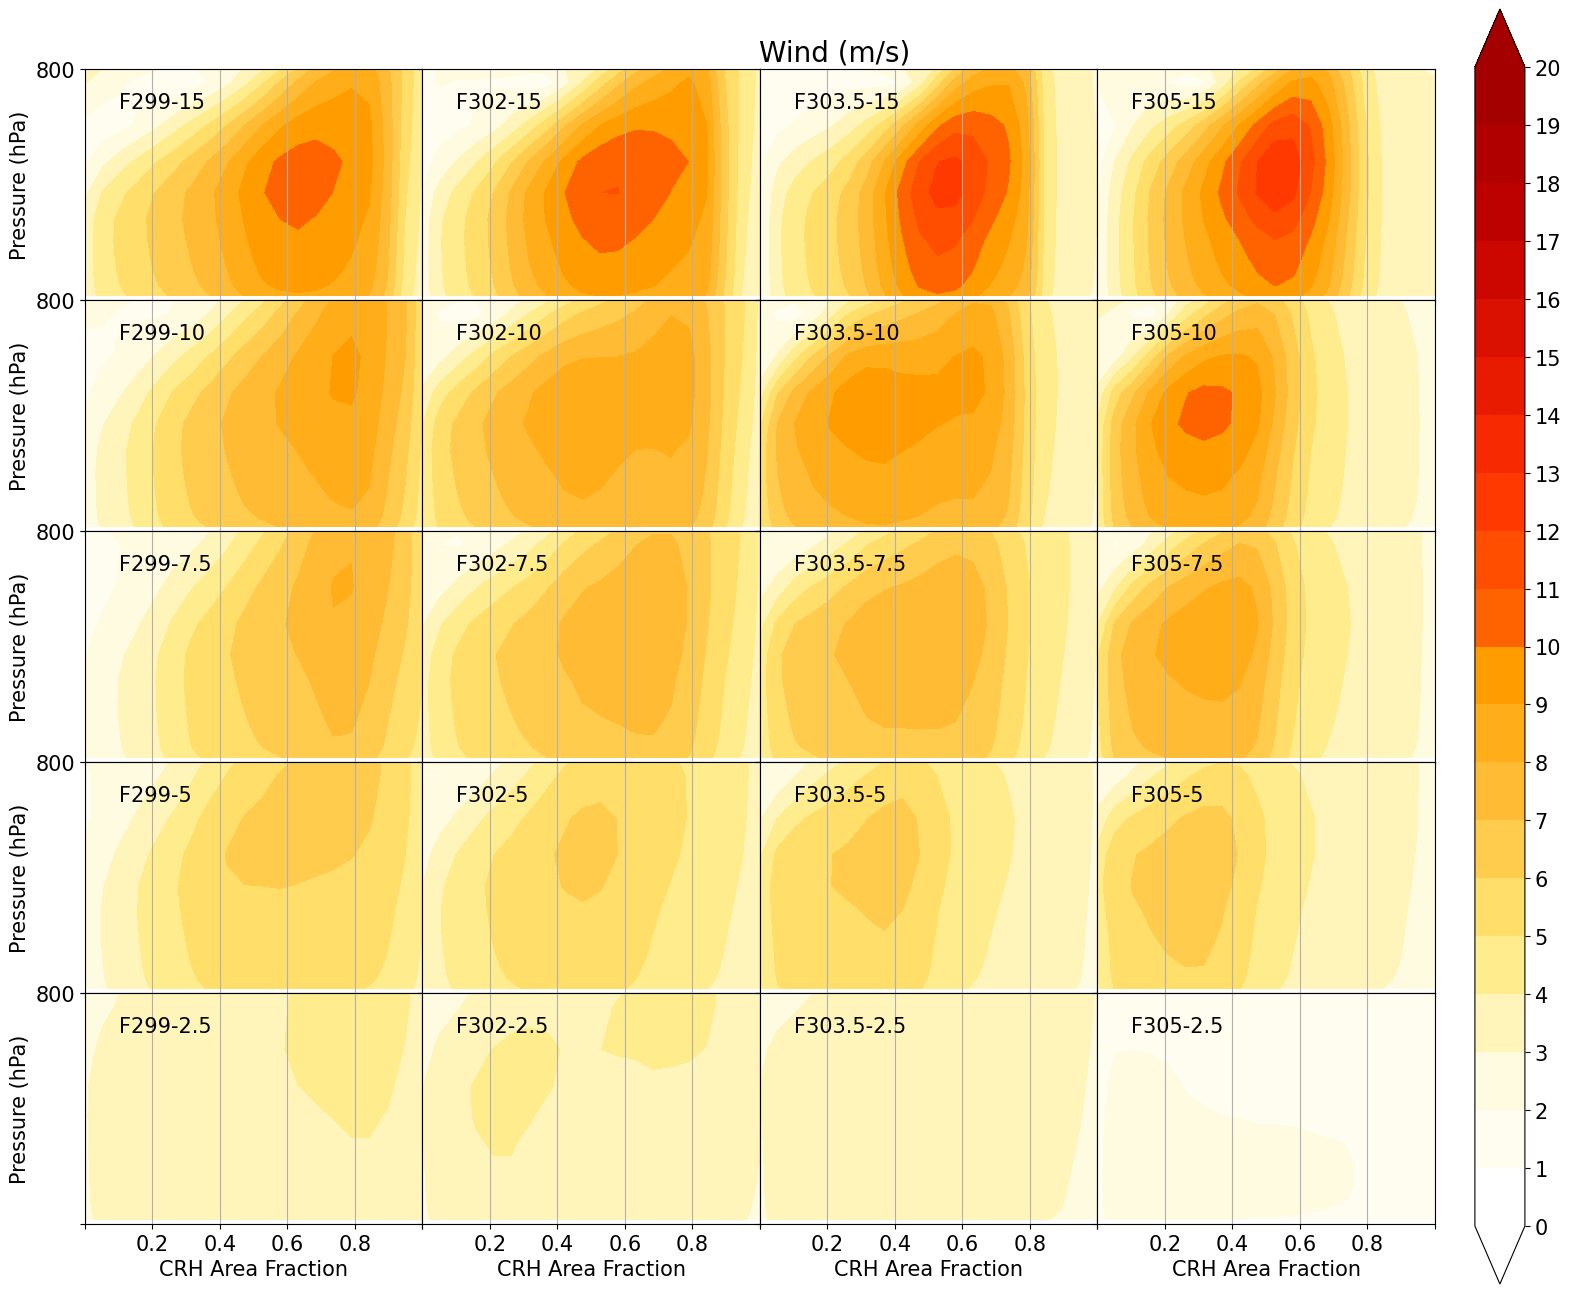

0
20
0.0


In [32]:
# Initialize variables
#stuff = 'temp'
ia = 1000
#stuff='cld_amt_dyn'
#stuff = 'stf'
#stuff = 'tdt_ls'
#stuff = 'vpp2db'
#stuff='tdt_lw_clr'
#stuff = 'tdt_lw'
#stuff = 'rh'
#stuff = 'rhov'
#stuff = 'mse'
#stuff = 'sspy'
#stuff = 'cld_amt_dyn'
#stuff = 'div'
#stuff = 'lwclrsubpy'
#stuff = 'tdtparamsubmpy'
#stuff = 'qsubmetpy'
#stuff = 'lwsubmetpy'
#stuff = 'CAPErh40u183'
#        csvnm = path + casenum + plot_this + str(eps1) '2dcrh.mat'
#stuff = 'mse'
#stuff='tdtconv'
#stuff = 'rh'
#stuff = 'ucomptc'
#stuff = 'div'
stuff = 'windspeed'
#stuff = 'ureturn'
#stuff = 'dstfdp'
dograd = 0#'h'
dobdl=0
dobdlb = 0
dosave = 1
#dobdlc =1
ib = 0
#if dobdlc:
#    ic = 600
#ib = 600
ib = 800
if stuff == 'sspy' or stuff == 'ssmetpy':
    ib = 300
gradstr=''
a=0
b=0
#if dobdl:
#    ib=400
sc=1
#casenumsc = ['f299rx3d2', 'f299rx2', 'f299rx3', 'fixedn1', 'f302rx3d2b',
#             'fixedn1x2', 'f302rx3', 'f303rd2', 'f303r1', 'f303rx3d2',
#             'f305rd2', 'fixedn1p3', 'f305rx3d2', 'f305rx2']
casenumsc = ['f299rd2','f299rx1','f299rx3d2', 'f299rx2', 'f299rx3', 'f302rd2','fixedn1', 'f302rx3d2b',
             'fixedn1x2', 'f302rx3', 'f303rd2', 'f303r1', 'f303rx3d2','f303rx2','f303rx3',
             'f305rd2', 'fixedn1p3', 'f305rx3d2', 'f305rx2','f305rx3']
#indssts = np.array([1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 4, 4, 4, 4])-1
#indranges = np.array([3, 4, 5, 2, 3, 4, 5, 1, 2, 3, 1, 2, 3, 4])-1
#indssts = [1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 4, 4, 4, 4]
#indranges = [3, 4, 5, 2, 3, 4, 5, 1, 2, 3, 1, 2, 3, 4]
indssts = [1,1,1, 1, 1, 2,2, 2, 2, 2, 3,3,3, 3, 3, 4,4, 4, 4, 4]
indranges = [1,2,3, 4, 5, 1,2, 3, 4, 5, 1, 2, 3,4,5, 1, 2, 3, 4,5]
cn = len(casenumsc)
cmap=gradsmap()

#try flippling so that high sst grad is on top
indranges = np.flip(indranges)

# Create a figure
fig, axs = plt.subplots(5, 4, figsize=(20, 15))  # Adjust figure size as needed
axs = axs.flatten()
plt.subplots_adjust(hspace=0, wspace=0)

# Dummy function to mimic gradsmap0 and gradsmap
#def gradsmap0():
#   pass

#def gradsmap():
#    pass

# Dummy function to load data from .mat files
def readvarnc(casenum, varname, default_value):
    filename = f'{casenum}{stuff}2dcrh.mat'
    if os.path.isfile(filename):
        data = loadmat(filename)
        return data.get(varname, default_value)
    else:
        return default_value

# Main loop
#pfull = readvarnc('fixedn1', 'pfull', 0)
path = '/home/disk/eos8/bdygert/code/compredo/'
for j in range(cn):
    casenum = casenumsc[j]
    flnm = path + casenum+stuff+'2dcrh.mat'
     # Plotting
    ax = axs[indssts[j] - 1 + (indranges[j] - 1) * 4]  # Adjust index for subplots
    if indssts[j]!=1:
        #ax.set_yticks([])
        ax.set_yticks([0,200,400,600,800,1000])
        ax.set_yticklabels([])
    else:
        ax.set_ylabel('Pressure (hPa)',fontsize=15)
        ax.set_yticks([0,200,400,600,800,1000])
        ax.set_yticklabels(['',200,400,600,800,''],fontsize=15)
    if indranges[j]!=5:
        #ax.set_xticks([])
        ax.set_xticks([0,.2,.4,.6,.8,1])
        ax.set_xticklabels([])

    else:
        ax.set_xlabel('CRH Area Fraction',fontsize=15)
        ax.set_xticks([0,.2,.4,.6,.8,1])
        ax.set_xticklabels(['',.2,.4,.6,.8,''],fontsize=15)

    if dobdl == 0:
        ax.set_ylim(ib, ia)
    ax.invert_yaxis()
    if os.path.isfile(flnm):
        data = loadmat(flnm)
        stf = data['stf']
        pfull=data['pfull']
        alin=data['alin']
    elif stuff == 'dstfdp':
        flnm = path + casenum+'stf2dcrh.mat'
        data = loadmat(flnm)
        stf = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        phalf = readnetcdf(casenum,'phalf')[:-1]
        p = readnetcdf(casenum,'pfull')
        #dp = np.gradient(phalf)
        stf = readstf(casenum,'stf')
        #dsdp=9.81*np.gradient(stf,dp,axis=1)
        stf=-9.81*np.gradient(stf,p,axis=1)        
        svnm = path + casenum+stuff+'2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    elif stuff.endswith('submpy'):
        flnm = path + casenum+stuff[:-6]+'2dcrh.mat'
        data = loadmat(flnm)
        qss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        flnm = path + casenum+'ssmetpy2dcrh.mat'
        data = loadmat(flnm)
        ss = data['stf']
        stf = np.divide(np.mean(qss[:-1,:,:],axis=2)*3600,ss) #hPa/hr
        svnm = path + casenum+stuff+'2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    elif stuff.endswith('subbpy'):
        flnm = path + casenum+stuff[:-6]+'2dcrh.mat'
        data = loadmat(flnm)
        qss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        flnm = path + casenum+'sspy2dcrh.mat'
        data = loadmat(flnm)
        ss = data['stf']
        stf = np.divide(qss*3600,ss) #hPa/hr
        svnm = path + casenum+stuff+'2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    elif stuff == 'sspy':
        g=9.81
        Cp = 1003.5
        flnm = path + casenum+'temp2dcrh.mat'
        data = loadmat(flnm)
        tss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        flnm = path + casenum+'z_full2dcrh.mat'
        data = loadmat(flnm)
        zss = data['stf']
        stf = np.gradient((tss+g*zss/Cp),pfull.ravel(),axis=1) #K/hPa
        svnm = path + casenum+'sspy2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    elif stuff == 'ssmetpy':
        Cp = 1003.5
        flnm = path + casenum+'temp2dcrh.mat'
        data = loadmat(flnm)
        tss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        ss= static_stability((pfull.T)*units.hPa,np.nanmean(tss,axis=2)*units.K,1) #(J/kghPa)
        stf = (ss.magnitude)/Cp
        stf=stf[:-1,:]
        svnm = path + casenum+'ssmetpy2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    elif stuff == 'lwsubmetpy':
        flnm = path + casenum+'tdt_lw2dcrh.mat'
        data = loadmat(flnm)
        qss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        flnm = path + casenum+'ssmetpy2dcrh.mat'
        data = loadmat(flnm)
        ss = data['stf']
        stf = np.divide(np.mean(qss[:-1,:,:],axis=2)*3600,ss) #hPa/hr
        svnm = path + casenum+'lwsubmetpy2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    elif stuff == 'ssvpy':
        g=9.81
        Cp = 1003.5
        flnm = path + casenum+'mse2dcrh.mat'
        data = loadmat(flnm)
        tss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        stf = np.gradient(tss/Cp,pfull.ravel(),axis=1) #K/hPa
        svnm = path + casenum+'ssvpy2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    elif stuff == 'qsubpy':
        flnm = path + casenum+'tdtconv2dcrh.mat'
        data = loadmat(flnm)
        qss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        flnm = path + casenum+'sspy2dcrh.mat'
        data = loadmat(flnm)
        ss = data['stf']
        stf = np.divide(qss/24,ss) #hPa/hr
        svnm = path + casenum+'qsubpy2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    elif stuff == 'qsubmetpy':
        flnm = path + casenum+'tdtconv2dcrh.mat'
        data = loadmat(flnm)
        qss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        flnm = path + casenum+'ssmetpy2dcrh.mat'
        data = loadmat(flnm)
        ss = data['stf']
        stf = np.divide(np.mean(qss[:-1,:,:],axis=2)/24,ss) #hPa/hr
        svnm = path + casenum+'qsubmetpy2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    elif stuff == 'lwsubpy':
        flnm = path + casenum+'tdt_lw2dcrh.mat'
        data = loadmat(flnm)
        qss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        flnm = path + casenum+'sspy2dcrh.mat'
        data = loadmat(flnm)
        ss = data['stf']
        stf = np.divide(qss*3600,ss) #hPa/hr
        svnm = path + casenum+'lwsubpy2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    elif stuff == 'lwsubmetpy':
        flnm = path + casenum+'tdt_lw2dcrh.mat'
        data = loadmat(flnm)
        qss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        flnm = path + casenum+'ssmetpy2dcrh.mat'
        data = loadmat(flnm)
        ss = data['stf']
        stf = np.divide(np.mean(qss[:-1,:,:],axis=2)*3600,ss) #hPa/hr
        svnm = path + casenum+'lwsubmetpy2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    elif stuff == 'netsubpy':
        flnm = path + casenum+'tdt_lw2dcrh.mat'
        data = loadmat(flnm)
        lwss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        flnm = path + casenum+'tdtconv2dcrh.mat'
        data = loadmat(flnm)
        css = data['stf']
        flnm = path + casenum+'tdtconv2dcrh.mat'
        data = loadmat(flnm)
        css = data['stf']
        flnm = path + casenum+'sspy2dcrh.mat'
        data = loadmat(flnm)
        ss = data['stf']
        stf = np.divide(qss*3600,ss) #hPa/hr
        svnm = path + casenum+'lwsubpy2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    elif stuff == 'lwvsubpy':
        flnm = path + casenum+'tdt_lw2dcrh.mat'
        data = loadmat(flnm)
        qss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        flnm = path + casenum+'ssvpy2dcrh.mat'
        data = loadmat(flnm)
        ss = data['stf']
        stf = np.divide(qss*3600,ss) #hPa/hr
        svnm = path + casenum+'lwsubpy2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    elif stuff == 'lwclrsubpy':
        flnm = path + casenum+'tdt_lw_clr2dcrh.mat'
        data = loadmat(flnm)
        qss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        flnm = path + casenum+'sspy2dcrh.mat'
        data = loadmat(flnm)
        ss = data['stf']
        stf = np.divide(qss*3600,ss) #hPa/hr
        svnm = path + casenum+'lwclrsubpy2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    else:
        continue
        # Replace with actual function call if needed
    #    stf, alin = binbycrh2d(casenum, stuff, 0, 0)
    if dograd == 'h':
        gradstr = 'Horizontal Gradient'
        stf = np.gradient(stf,axis=0)
    else:
        gradstr = ''
    
    if dobdl == 1:
        ii=12#19 #15
        pfull = pfull[ii:]
        stf = stf[:, ii:, :]
    elif dobdl == 2:
        pfull = pfull[15:23]
        stf = stf[:, 15:23, :]
    elif dobdl == 3:
        pfull = pfull[12:23]
        stf = stf[:, 12:23, :]
    elif dobdl == 4:
        pfull = pfull[8:]
        stf = stf[:, 8:, :]
    
    # Apply transformations based on 'stuff'
    if stuff == 'tdt_lw':
        stf = stf * -24 * 3600
        lab = 'Longwave Cooling (K/day)'
    elif stuff == 'tdt_lw_clr':
        stf = stf * -24 * 3600
        lab = 'Longwave Cooling CLR (K/day)'
    elif stuff == 'rh':
        lab = 'RH (%)'
    else:
        lab = ''  # Default label
    if len(np.shape(stf))>2:
        stfm = np.nanmean(stf, axis=2)
        stfm=stfm[:-1,:]
    else:
        stfm=stf
    a = np.nanmin([np.nanmin(stfm),a])
    b = np.nanmax([np.nanmax(stfm),b])
    
    # Define contours
    if stuff == 'cld_amt_dyn' and dobdl==1:
        a = 0
        b = .3
        ib = 600
        scmap = gradsmap0()
    elif stuff == 'cld_amt_dyn':
        #a = 0
        #b = 1
        #scmap = gradsmap0()
        a=0
        b=.3
        dc = .05
        #scmap='Purples'
        dcn = len(np.arange(a,b+dc,dc))
        scmap=gradsmap0n((dcn,3))
        #scmap = gradsmap0()
    elif stuff=='liq_wat':
        a=0
        b=0.05
        sc=1000
    elif stuff=='ice_wat':
        a=0
        b=0.2
        sc=1000
        scmap = gradsmap0()
    elif stuff == 'tdtconv' and dobdl:
        a = -8
        b = 8
    elif stuff == 'tdtconv':
        #a = -9
        a=0
        b = 9
        dc = .5
        scmap = 'Reds'
    elif stuff == 'tdt_conv':
        #a = -9
        a=0
        b = 9
        scmap = 'Reds'
    elif stuff =='dstfdp':
        a= -1
        b =1
        #fudge colorbar
        a=-.45
        b=.45
        dc = .05
        scmap = gradsmap()
    elif stuff == 'tdt_ls':
        a = -9
        stfm = stfm*24*3600
        #a=0
        b = 9
        scmap = 'Reds'
    elif stuff == 'cloud_area':
        a = 0
        b = 1
        scmap = gradsmap0()
    elif stuff == 'acre':
        a=-3.5
        b=3.5
        scmap=gradsmap()
    elif stuff == 'mse' and dograd ==0:
        a=2*10**2
        b=4.5*10**2
        stfm=stfm/1000
        scmap=gradsmap()
    elif stuff == 'mse' and dograd =='h':
        a=-13
        b=13
        stfm=stfm/1000
        scmap=gradsmap()
          
    elif stuff == 'tdtlwsw':
        a=-9
        b=9
        dc = .5
        scmap=gradsmap()
    elif stuff == 'rhov' and dograd=='h':
        a =-.01
        b = .01
        scmap = gradsmap()
    elif stuff == 'rhov':
        a = 0
        b = 1.5
        scmap = gradsmap0()
    elif 'tdt_lw' in stuff:
        #a = -9
        a=0
        b = 9
        dc = .5
        scmap='Blues'
    elif stuff == 'rh':
        a = 0
        b = 100
        dc = 5
        #scmap = 'BrBG'
        scmap=gradsmapf()
    elif stuff == 'ucomptc':
        a = -10
        b = 10
        scmap=gradsmap()
        doreturn=0
        if doreturn:
            a = 0
            b = 15
            stfm[stfm>0]=np.nan
            stfm = stfm*-1;
            scmap=gradsmap0()
    elif stuff == 'ureturn':
        a = -15
        b = 15
        #stfm = stfm*-1;
        #scmap = 'BrBG'
        scmap=gradsmap0()
    elif stuff == 'sphum':
        a = 0
        b = 0.022
    elif stuff == 'stf':
        a = 0
        b = 15
        dc = 1
        #scmap='Purples'
        dcn = len(np.arange(a,b+dc,dc))
        scmap=gradsmap0n((dcn,3))
        #scmap = gradsmap0()
    elif stuff == 'ss':
        a = 0
        b = 0.2
    elif stuff == 'ssb':
        a = 0
        b = 15
    elif stuff == 'sspy':
        a = -.3
        b = .3
        stfm = -1*stfm
        #stfm[np.abs(stfm)<a] = np.nan
        scmap = gradsmap()
    elif stuff == 'ssmetpy':
        a = -1e-4
        b = 1e-4
        #stfm = -1*stfm
        #stfm[np.abs(stfm)>b] = np.nan
        scmap = gradsmap()
    elif stuff == 'ssvpy':
        a = -.3
        b = .3
        stfm = -1*stfm
        #stfm[np.abs(stfm)<a] = np.nan
        scmap = gradsmap()
    elif stuff == 'lwsubpy':
        a = -8
        b = 8
        stfm[np.abs(stfm)>b] = np.nan
        scmap=gradsmap()
    elif stuff == 'lwsubmetpy':
        a = -1
        b = 1
        stfm = stfm
        stfm[np.abs(stfm)>b] = np.nan
        scmap=gradsmap()
    elif stuff == 'lwclrsubpy':
        a = -6.5
        b = 6.5
        stfm[np.abs(stfm)>b] = np.nan
        scmap=gradsmap()
    elif stuff == 'qsubpy':
        a = -6.5
        b = 6.5
        stfm[np.abs(stfm)>b] = np.nan
        scmap=gradsmap()
    elif stuff == 'qfluxh':
        a = -3.5e-3
        b = 3.5e-3
    elif stuff == 'vpp2db':
        a = 0
        b = 150
        scmap = gradsmap0()
        stfm = stfm*10e-7
    elif stuff == 'div' and dobdl==1:
        a = -5e-6
        b = 5e-6
        scmap = gradsmap()
    elif stuff == 'div':
        a = -8e-6
        b = 8e-6
        scmap = gradsmap()
    elif stuff == 'omega':
        a = -6.5
        b = 6.5
        dc = 0.5
        dcn = len(np.arange(a,b+dc,dc))
        scmap=gradsmapn((dcn,3))
        #scmap=gradsmap()
    elif stuff == 'n2':
        a = 0.2
        b = 2
    elif stuff == 'mc':
        a = 0
        b = 0.02
    elif stuff == 'windspeed':
        a = 0
        b = 20
        dc = 1
        #scmap='Purples'
        dcn = len(np.arange(a,b+dc,dc))
        scmap=gradsmap0n((dcn,3))
    elif stuff.startswith('CAPE'):
        a= 0
        b= 150
        scmap = gradsmap0()
    elif stuff == 'sphumadvp' or 'sub' in stuff:
        if dobdl == 2:
            a = 2e-3
            b = -2e-3
        else:
            a = 5e-3
            b = -5e-3
    elif stuff == 'temp' and dograd=='h':
        a = -3
        b = 3
    elif stuff == 'temp':
        a = 200
        b = 310
    else:
        scmap = gradsmap()
    if stuff == 'qadvzb' and dobdl == 2:
        a = 5e-3
        b = -5e-3
    # Plotting
   # ax = axs[indssts[c] - 1 + (indranges[c] - 1) * 4]  # Adjust index for subplots
    #connum=10
    #connum=15
    connum=20
    if a * b < 0:
        #gradsmap()
        c = max(abs(a), abs(b))
        a = -c
        b = c
        contl = np.concatenate([np.linspace(-c, 0, connum-1)[:-1], np.linspace(0, c, connum-1)])
    else:
        #gradsmap0()
        contl = np.linspace(a, b, connum)
    if 'dc' in locals():
        contl = np.arange(a,b+dc,dc)
    #print(contl)
    cax = ax.contourf(np.ravel(alin), np.ravel(pfull), sc*stfm.T, levels=contl, cmap=scmap, extend='both')
    cax.set_clim([a,b])
    ax.text(0.1, 0.9, newcasenum(casenum), fontsize=15,horizontalalignment='left', verticalalignment='top', transform=ax.transAxes)
    #cax = ax.contourf(np.ravel(alin), np.ravel(pfull), stfm[:-1,:].T, levels=contl, cmap='viridis', extend='both')
    #ax.contour(np.ravel(alin), np.ravel(pfull), stfm[:-1,:].T, levels=[0], colors='k')
    ax.grid(True)
 #   ax.set_xticks([])
 #   ax.set_yticks([])
 #   ax.set_ylim(pfull[0], pfull[-1])
 #   ax.invert_yaxis()
  #  ax.grid(True)
tstr = newlab(stuff) + gradstr
# Save and upload plot
svnm=stuff+'crhareasubplots.png'
plt.savefig(svnm, dpi=300)
# uploadToDropbox(f'{stuff}crhareasubplots.png')  # Implement the Dropbox upload function if needed
#fig.subplots_adjust(right=0.8)
#cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
#(left, bottom, width, height)
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.82, 0.07, 0.025, .85])
#norm = mcolors.Normalize(vmin=a, vmax=b)
#mappable = cm.ScalarMappable(norm=norm, cmap=scmap)
#cbar = fig.colorbar(mappable, ax=ax)
cbar = fig.colorbar(cax, cax=cbar_ax)
if stuff=='omega':
    cbar.ax.set_yticks(contl[::2])
    cbar.ax.set_yticklabels(np.round(contl[::2],2),fontsize=15)
else:
    cbar.ax.set_yticks(contl)
    cbar.ax.set_yticklabels(np.round(contl,2),fontsize=15)
#cbar.ax.set_yticklabels(np.round(contl,2),fontsize=15)
plt.rcParams['font.size'] = 15
fig.suptitle(tstr, y=.9,fontsize=20)
if dosave:
    fname = stuff + 'fixedsstsubplotsa.pdf'
    plt.savefig(fname, dpi=400)
#plt.savefig(fname, *, transparent=None, dpi=400, format=None,
#        metadata=None, bbox_inches=None, pad_inches=0.1,
#        facecolor='auto', edgecolor='auto', backend=None,
#        **kwargs
#       )

#fig.colorbar(cax, cax=cbar_ax)
plt.show()
print(a)
print(b)
print(np.mean(a))

In [7]:
path = '/home/disk/eos8/bdygert/code/compredo/'
casenumsc = ['f299rd2','f299rx1','f299rx3d2', 'f299rx2', 'f299rx3', 'f302rd2','fixedn1', 'f302rx3d2b',
             'fixedn1x2', 'f302rx3', 'f303rd2', 'f303r1', 'f303rx3d2','f303rx2','f303rx3',
             'f305rd2', 'fixedn1p3', 'f305rx3d2', 'f305rx2','f305rx3']
indssts = np.array([1,1,1, 1, 1, 2,2, 2, 2, 2, 3,3,3, 3, 3, 4,4, 4, 4, 4])
indranges = np.array([1,2,3, 4, 5, 1,2, 3, 4, 5, 1, 2, 3,4,5, 1, 2, 3, 4,5])
ssts = ['299', '302', '303.5','305']
ranges = ['2.5','5','7.5','10','15']
cvals = np.zeros(np.size(casenumsc))
#stuff = 'CAPErh80u3'
#stuff = 'CAPErh80u4'
stuff = 'tdtconv'
#stuff = 'CAPE3'
#stuff = 'CINrh80u3'
#stuff = 'CINrh80u4'

#stuff = 'CIN4'
dop = 0
aa=12
ab = 16
cn = len(casenumsc)
for j in range(cn):
    casenum = casenumsc[j]
    flnm = path + casenum+stuff+'2dcrh.mat'    
    if os.path.isfile(flnm):
        data = loadmat(flnm)
        stf = data['stf']
        pfull=data['pfull']
        alin=data['alin']
    elif stuff.endswith('submpy'):
        flnm = path + casenum+stuff[:-6]+'2dcrh.mat'
        data = loadmat(flnm)
        qss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        flnm = path + casenum+'ssmetpy2dcrh.mat'
        data = loadmat(flnm)
        ss = data['stf']
        stf = np.divide(np.mean(qss[:-1,:,:],axis=2)*3600,ss) #hPa/hr
        svnm = path + casenum+stuff+'2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    elif stuff.endswith('subbpy'):
        flnm = path + casenum+stuff[:-6]+'2dcrh.mat'
        data = loadmat(flnm)
        qss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        flnm = path + casenum+'sspy2dcrh.mat'
        data = loadmat(flnm)
        ss = data['stf']
        stf = np.divide(qss*3600,ss) #hPa/hr
        svnm = path + casenum+stuff+'2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    elif stuff == 'sspy':
        g=9.81
        Cp = 1003.5
        flnm = path + casenum+'temp2dcrh.mat'
        data = loadmat(flnm)
        tss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        flnm = path + casenum+'z_full2dcrh.mat'
        data = loadmat(flnm)
        zss = data['stf']
        stf = np.gradient((tss+g*zss/Cp),pfull.ravel(),axis=1) #K/hPa
        svnm = path + casenum+'sspy2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    elif stuff == 'ssmetpy':
        Cp = 1003.5
        flnm = path + casenum+'temp2dcrh.mat'
        data = loadmat(flnm)
        tss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        ss= static_stability((pfull.T)*units.hPa,np.nanmean(tss,axis=2)*units.K,1) #(J/kghPa)
        stf = (ss.magnitude)/Cp
        stf=stf[:-1,:]
        svnm = path + casenum+'ssmetpy2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    elif stuff == 'lwsubmetpy':
        flnm = path + casenum+'tdt_lw2dcrh.mat'
        data = loadmat(flnm)
        qss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        flnm = path + casenum+'ssmetpy2dcrh.mat'
        data = loadmat(flnm)
        ss = data['stf']
        stf = np.divide(np.mean(qss[:-1,:,:],axis=2)*3600,ss) #hPa/hr
        svnm = path + casenum+'lwsubmetpy2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    elif stuff == 'ssvpy':
        g=9.81
        Cp = 1003.5
        flnm = path + casenum+'mse2dcrh.mat'
        data = loadmat(flnm)
        tss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        stf = np.gradient(tss/Cp,pfull.ravel(),axis=1) #K/hPa
        svnm = path + casenum+'ssvpy2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    elif stuff == 'qsubpy':
        flnm = path + casenum+'tdtconv2dcrh.mat'
        data = loadmat(flnm)
        qss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        flnm = path + casenum+'sspy2dcrh.mat'
        data = loadmat(flnm)
        ss = data['stf']
        stf = np.divide(qss/24,ss) #hPa/hr
        svnm = path + casenum+'qsubpy2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    elif stuff == 'qsubmetpy':
        flnm = path + casenum+'tdtconv2dcrh.mat'
        data = loadmat(flnm)
        qss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        flnm = path + casenum+'ssmetpy2dcrh.mat'
        data = loadmat(flnm)
        ss = data['stf']
        stf = np.divide(np.mean(qss[:-1,:,:],axis=2)/24,ss) #hPa/hr
        svnm = path + casenum+'qsubmetpy2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    elif stuff == 'lwsubpy':
        flnm = path + casenum+'tdt_lw2dcrh.mat'
        data = loadmat(flnm)
        qss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        flnm = path + casenum+'sspy2dcrh.mat'
        data = loadmat(flnm)
        ss = data['stf']
        stf = np.divide(qss*3600,ss) #hPa/hr
        svnm = path + casenum+'lwsubpy2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    elif stuff == 'lwsubmetpy':
        flnm = path + casenum+'tdt_lw2dcrh.mat'
        data = loadmat(flnm)
        qss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        flnm = path + casenum+'ssmetpy2dcrh.mat'
        data = loadmat(flnm)
        ss = data['stf']
        stf = np.divide(np.mean(qss[:-1,:,:],axis=2)*3600,ss) #hPa/hr
        svnm = path + casenum+'lwsubmetpy2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    elif stuff == 'netsubpy':
        flnm = path + casenum+'tdt_lw2dcrh.mat'
        data = loadmat(flnm)
        lwss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        flnm = path + casenum+'tdtconv2dcrh.mat'
        data = loadmat(flnm)
        css = data['stf']
        flnm = path + casenum+'tdtconv2dcrh.mat'
        data = loadmat(flnm)
        css = data['stf']
        flnm = path + casenum+'sspy2dcrh.mat'
        data = loadmat(flnm)
        ss = data['stf']
        stf = np.divide(qss*3600,ss) #hPa/hr
        svnm = path + casenum+'lwsubpy2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    elif stuff == 'lwvsubpy':
        flnm = path + casenum+'tdt_lw2dcrh.mat'
        data = loadmat(flnm)
        qss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        flnm = path + casenum+'ssvpy2dcrh.mat'
        data = loadmat(flnm)
        ss = data['stf']
        stf = np.divide(qss*3600,ss) #hPa/hr
        svnm = path + casenum+'lwsubpy2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    elif stuff == 'lwclrsubpy':
        flnm = path + casenum+'tdt_lw_clr2dcrh.mat'
        data = loadmat(flnm)
        qss = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        flnm = path + casenum+'sspy2dcrh.mat'
        data = loadmat(flnm)
        ss = data['stf']
        stf = np.divide(qss*3600,ss) #hPa/hr
        svnm = path + casenum+'lwclrsubpy2dcrh.mat'
        savemat(svnm,{'stf':stf,'alin':alin,'pfull':pfull})
    else:
        continue
    if stuff == 'CAPE3' and dop==0:
        print('herehere')
        ylab = 'CAPE (J)'
        tstr = 'CAPE to 500 hPa, averaged over .6-.8 CRH'
        cvals[j] = np.nanmean(np.nansum(stf[aa:ab,16:],1))
    elif stuff == 'CAPE3' and dop==1:
        print('hereherehere')
        ylab = 'Negative Buoyancy Pressure Level (hPa)'
        tstr = 'LNB, averaged over .6-.8 CRH'
        pb = np.tile(pfull,[1,20]).T
        pb[stf>0] = np.nan
        pmax = np.nanmax(pb,1)
        cvals[j] = np.nanmean(np.nanmean(pmax[aa:ab]))
    elif stuff == 'CAPE4' and dop==1:
        print('hereherehere')
        ylab = 'Negative Buoyancy Pressure Level (hPa) (.45)'
        tstr = 'LNB, averaged over .6-.8 CRH'
        pb = np.tile(pfull,[1,20]).T
        pb[stf>0] = np.nan
        pmax = np.nanmax(pb,1)
        cvals[j] = np.nanmean(np.nanmean(pmax[aa:ab]))
    elif stuff == 'CAPErh80u3' and dop==1:
        print('here?')
        ylab = 'Negative Buoyancy Pressure Level (hPa)'
        tstr = 'LNB (RH = 80%), averaged over .6-.8 CRH'
        pb = np.tile(pfull,[1,20]).T
        pb[stf>0] = np.nan
        pmax = np.nanmax(pb,1)
        cvals[j] = np.nanmean(np.nanmean(pmax[aa:ab]))
    elif stuff == 'CIN3':
        ylab = 'CIN (J)'
        tstr = 'CIN to 500 hPa, averaged over .6-.8 CRH'
        cvals[j] = np.nanmean(np.nansum(stf[aa:ab,16:],1))
    elif stuff == 'CIN4':
        ylab = 'CIN (J)'
        tstr = 'CIN to 500 hPa, averaged over .6-.8 CRH'
        cvals[j] = np.nanmean(np.nansum(stf[aa:ab,16:],1))
    elif stuff == 'CAPErh80u3' and dop == 0:
        print('no here')
        ylab = 'CAPE (J)'
        tstr = 'CAPE (80 RH) to 500 hPa, averaged over .6-.8 CRH'
        cvals[j] = np.nanmean(np.nansum(stf[aa:ab,16:],1))
    elif stuff == 'tdt_lw' and dop == 0:
        ylab = 'LW Cooling K/day'
        tstr = 'LW Cooling to 500 hPa, averaged over .6-.8 CRH'
        #stf[stf>0] = np.nan
        print(np.max(stf[:]))
        stf = stf*24*3600*-1
        cvals[j] = np.nanmean(np.nanmean(stf[aa:ab,16:],1))
    elif stuff == 'tdtconv' and dop == 0:
        ylab = 'Q K/day'
        tstr = 'Heating from Convection to 500 hPa, averaged over .6-.8 CRH'
        #stf[stf>0] = np.nan
        #print(np.max(stf[:]))
        #stf = stf*24*3600*-1
        cvals[j] = np.nanmean(np.nanmean(stf[aa:ab,16:],1))
    elif stuff == 'CAPErh80u4' and dop == 1:
        print('no here')
        ylab = 'CAPE (J)'
        tstr = 'CAPE (80 RH) to 500 hPa, averaged over .6-.8 CRH (.45)'
        cvals[j] = np.nanmean(np.nansum(stf[aa:ab,16:],1))
    elif stuff == 'tdtconv':
        ylab = newlab(stuff)
        cvals[j] = np.nanmean(np.nansum(stf[aa:ab,16:],1))
        tstr = newlab(stuff)+'to 500 hPa, averaged over .6-.8 CRH'
print(stuff)

tdtconv


/tmp/ipykernel_3443573/3830558586.py:13: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(ranges,cvals[indssts==(i+1)],20,c=colors[i])


Text(0.5, 1.0, 'Heating from Convection to 500 hPa, averaged over .6-.8 CRH')

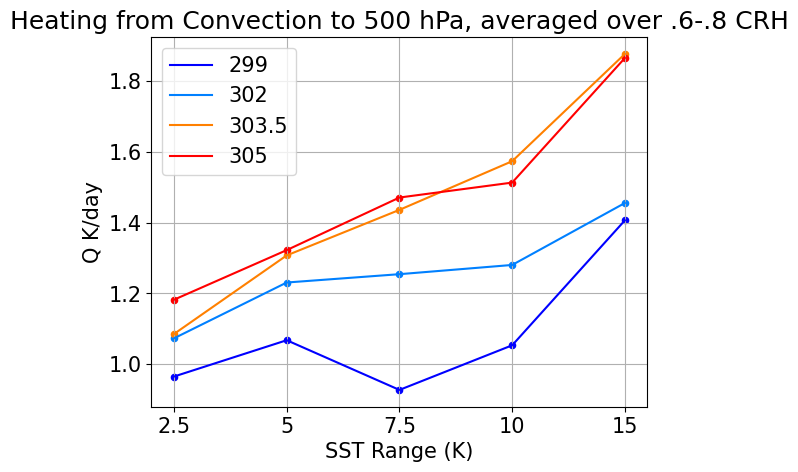

In [8]:
#colors = ['red','orange','blue','cyan']
nv = 0
ofs = 0
colors = np.array([
        [ofs, ofs, 255],
        [nv, 128+nv, 255],
        [255, 128+nv, nv],
        [255, ofs, ofs],
    ]) / 255.0
    
for i in range(0,4):
    plt.plot(ranges,cvals[indssts==(i+1)],color=colors[i,:],label=ssts[i])
    plt.scatter(ranges,cvals[indssts==(i+1)],20,c=colors[i])
if dop:
    plt.gca().invert_yaxis()
plt.legend()
plt.grid()
plt.ylabel(ylab)
plt.xlabel('SST Range (K)')
plt.title(tstr)


/tmp/ipykernel_3443573/1144387978.py:14: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(ssts,cvals[indranges==(i+1)],20,c=colors[i])


Text(0.5, 1.0, 'Heating from Convection to 500 hPa, averaged over .6-.8 CRH')

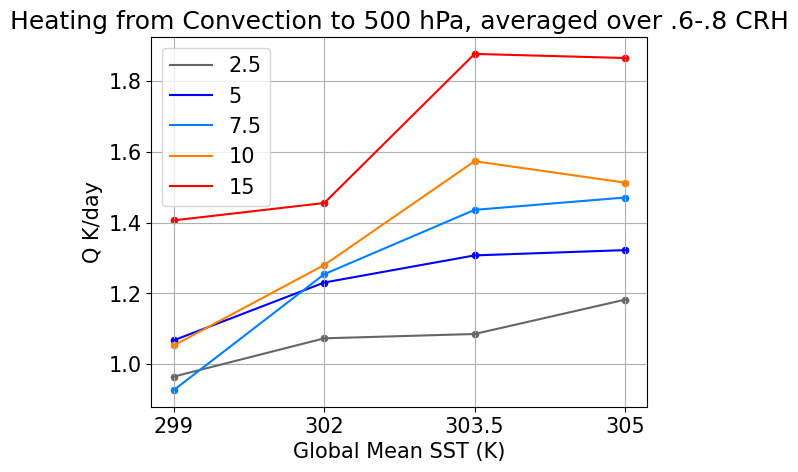

In [9]:
#colors = ['purple','blue','cyan','orange','red']
nv = 0
ofs = 0
vv = 102
colors = np.array([
        [vv,vv,vv],
        [ofs, ofs, 255],
        [nv, 128+nv, 255],
        [255, 128+nv, nv],
        [255, ofs, ofs],
    ]) / 255.0
for i in range(0,5):
    plt.plot(ssts,cvals[indranges==(i+1)],color=colors[i],label=ranges[i])
    plt.scatter(ssts,cvals[indranges==(i+1)],20,c=colors[i])
if dop:
    plt.gca().invert_yaxis()
plt.legend()
plt.grid()
plt.xlabel('Global Mean SST (K)')
plt.ylabel(ylab)
plt.title(tstr)

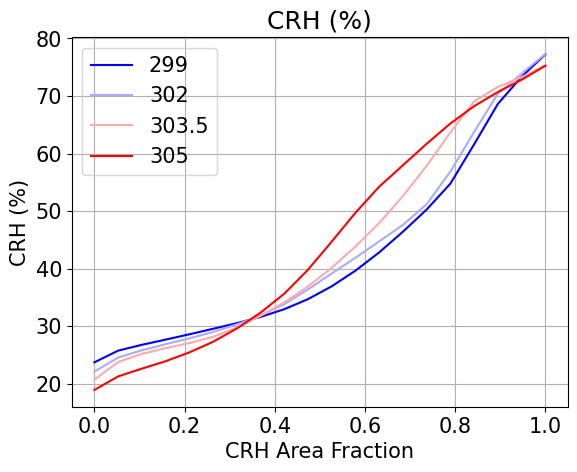

In [12]:
path = '/home/disk/eos8/bdygert/code/compredo/'
casenumsc = ['f299rd2','f299rx1','f299rx3d2', 'f299rx2', 'f299rx3', 'f302rd2','fixedn1', 'f302rx3d2b',
             'fixedn1x2', 'f302rx3', 'f303rd2', 'f303r1', 'f303rx3d2','f303rx2','f303rx3',
             'f305rd2', 'fixedn1p3', 'f305rx3d2', 'f305rx2','f305rx3']
cn = len(casenumsc)
vvar = 'crh'
tlab = 'CRH (%)'
#fname = vvar+'fixedsststf.pdf'
#fname = 'fig9a.pdf'

dossts=1
indssts = np.array([1,1,1, 1, 1, 2,2, 2, 2, 2, 3,3,3, 3, 3, 4,4, 4, 4, 4])
indranges = np.array([1,2,3, 4, 5, 1,2, 3, 4, 5, 1, 2, 3,4,5, 1, 2, 3, 4,5])
ssts = ['299', '302', '303.5','305']
ranges = ['2.5','5','7.5','10','15']
if dossts:
    stfs = np.ones((20,4))
    colors = plt.cm.bwr(np.linspace(0,1,np.shape(stfs)[1]))
else:
    stfs = np.ones((20,5))
    colors = plt.cm.Reds(np.linspace(0,1,np.shape(stfs)[1]+1))
    colors = colors[1:]

stfs[:] = np.nan
for j in range(cn):
    casenum = casenumsc[j]
    flnm = path + casenum+vvar+'2dcrh.mat'    
    if os.path.isfile(flnm):
        data = loadmat(flnm)
        stf = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        stf = np.mean(stf,2)
        #plt.plot(alin.T,stf[:-1,0],label=newcasenum(casenum))
    if dossts:
        indc = indssts[j]-1
    else:
        indc = indranges[j]-1
    stfs[:,indc] = np.nanmean([stfs[:,indc],stf[:-1,0]],0)
for pi in range(0,np.shape(stfs)[1]):
    if dossts:
        plab = str(ssts[pi])
    else:
        plab = str(ranges[pi])
    #plt.plot(alin.T,stfs[:,pi],label=newcasenum(casenum))
    plt.plot(alin.T,stfs[:,pi],color=colors[pi],label=plab)
plt.legend(loc = "upper left",facecolor='none')
plt.grid('true')
plt.title(tlab)
plt.xlabel('CRH Area Fraction')
plt.ylabel(tlab)
plt.rcParams['font.size'] = 15
#plt.savefig(fname, dpi=400)
#dosave =1
#if dosave:
#    fname = 'fixedsststfval.pdf'
#    plt.savefig(fname, dpi=400)
plt.show()
#plt.contourf(np.ravel(alin), np.ravel(pfull), stf.T, cmap=scmap, extend='both')
#plt.colorbar()

CAPErh40maxu233
CAPErh40maxu213
CAPErh40maxu193
CAPErh40maxu183
CAPE3


/tmp/ipykernel_3443573/3101865909.py:105: RuntimeWarning: Mean of empty slice
  stfp = np.nanmean(stf[12:16,:],0)


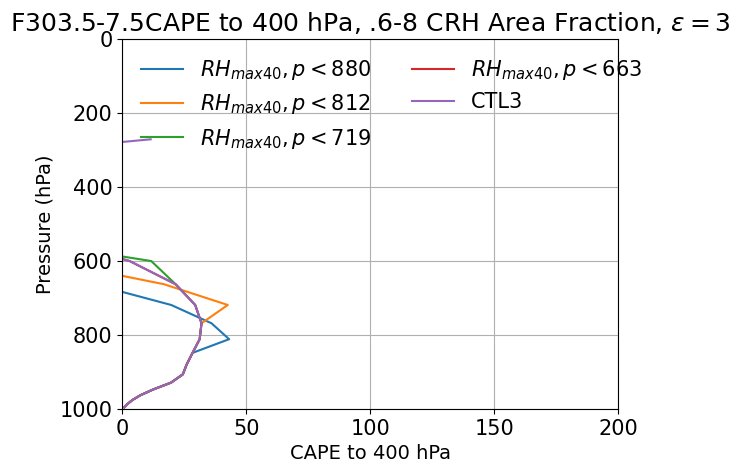

In [23]:
#subplots
path = '/home/disk/eos8/bdygert/code/compredo/'
casenumsc = ['f299rd2','f299rx1','f299rx3d2', 'f299rx2', 'f299rx3', 'f302rd2','fixedn1', 'f302rx3d2b',
             'fixedn1x2', 'f302rx3', 'f303rd2', 'f303r1', 'f303rx3d2','f303rx2','f303rx3',
             'f305rd2', 'fixedn1p3', 'f305rx3d2', 'f305rx2','f305rx3']
cn = len(casenumsc)
pfull = pfull.ravel()
#vvar = 'crh'
#tlab = 'CRH (%)'
#vvar = 'crh'
#tlab = 'CRH (%)'
#vvar = 'CAPE3'
#tlab = 'CAPE to 400 hPa'
#vvar = 'CAPErh80u3'
#tlab = 'CAPE to 400 hPa (RH=80)'
#vvar = 'CAPErh40u3'
#tlab = 'CAPE to 400 hPa (RH=40 at 600 hPa)'
ev=3
vvar = 'CAPErh40maxu233'
s='$RH_{max40}, p<$'
#llabs = [s+str(round(pfull[23])),s+str(round(pfull[21])),s+str(round(pfull[19])),s+str(round(pfull[18])),'CTL3','CTL2','CTL0','CAPEpy']
llabs = [s+str(round(pfull[24])),s+str(round(pfull[22])),s+str(round(pfull[20])),s+str(round(pfull[19])),'CTL3','CTL2','CTL0','CAPEpy']

#tlab = 'CAPE to 400 hPa (RH=40 Max at 600 hPa)'
xstr = 'CAPE to 400 hPa'
tlab = 'Pressure (hPa)'
pv=15
sstx = 0
#vvar = 't_surf'
#tlab = 'SST Anomalies (K)'
dossts=0
indssts = np.array([1,1,1, 1, 1, 2,2, 2, 2, 2, 3,3,3, 3, 3, 4,4, 4, 4, 4])
indranges = np.array([1,2,3, 4, 5, 1,2, 3, 4, 5, 1, 2, 3,4,5, 1, 2, 3, 4,5])
ssts = ['299', '302', '303.5','305']
ranges = ['2.5','5','7.5','10','15']
pi = 3
pj = 3
j = 12
if ev==2:
    ttlab = newcasenum(casenumsc[j])+'CAPE to 400 hPa, .6-8 CRH Area Fraction, $\epsilon=2$'
    #vvars = ['CAPErh40maxu232','CAPErh40maxu212','CAPErh40maxu192','CAPErh40maxu182','CAPE3','CAPE2','CAPE0','pyCAPE']
    vvars = ['CAPErh40maxu232','CAPErh40maxu212','CAPErh40maxu192','CAPErh40maxu182','CAPE2']
    llabs = [s+str(round(pfull[24])),s+str(round(pfull[22])),s+str(round(pfull[20])),s+str(round(pfull[19])),'CTL2']


elif ev==3:
    vvars = ['CAPErh40maxu233','CAPErh40maxu213','CAPErh40maxu193','CAPErh40maxu183','CAPE3']
    ttlab = newcasenum(casenumsc[j])+'CAPE to 400 hPa, .6-8 CRH Area Fraction, $\epsilon=3$'
    llabs = [s+str(round(pfull[24])),s+str(round(pfull[22])),s+str(round(pfull[20])),s+str(round(pfull[19])),'CTL3']


#llabs = [s+str(round(pfull[24])),s+str(round(pfull[22])),s+str(round(pfull[20])),s+str(round(pfull[19])),'CTL3','CTL2','CTL0','CAPEpy']

if dossts:
    colors = plt.cm.Reds(np.linspace(0,1,6))
    colors = colors[1:]
    sz1=4
    sz2=5
else:
    colors = plt.cm.bwr(np.linspace(0,1,4))
    sz1=5
    sz2=4
crhs = np.ones((20,4,5))
crhs[:] = np.nan
tsurfs = np.ones((20,4,5))
tsurfs[:] = np.nan
for v in range(0,len(vvars)):
    vvar = vvars[v]
    print(vvar)
    #for j in range(cn):
    casenum = casenumsc[j]
    flnm = path + casenum+vvar+'2dcrh.mat'    
    if os.path.isfile(flnm):
        data = loadmat(flnm)
        stf = data['stf']
        pfull=data['pfull']
        alin=data['alin']
    elif vvar == 'pyCAPE':
        flnm = path + casenum+'temp2dcrh.mat'
        data = loadmat(flnm)
        temp0 = data['stf']
        temp0=np.mean(temp0[0:20,:,:],2)
        flnm = path + casenum+'rh2dcrh.mat'
        data = loadmat(flnm)
        rh0 = data['stf']
        rh0 = np.mean(rh0[0:20,:,:],2)/100
        pfull0=data['pfull']
        pfull0 = np.ravel(pfull0)
        stf = np.zeros(np.shape(temp0))
        stf[:] = np.nan
        alin = np.linspace(0,1,20)
        ptest = np.ravel(pfull0)*units.hPa
        ptest = ptest[15:]
        for t in range(0,20):  
            ttest = (temp0[t,15:]-273.15)* units.degC
            rhtest = rh0[t,15:]
            Td = dewpoint_from_relative_humidity(ttest, rhtest)
            csvnm = path + casenum + vvar + '2dcrh.mat'
            x,y = surface_based_cape_cin(np.flip(ptest), np.flip(ttest), np.flip(Td))
            stf[t,31] = x.magnitude
        savemat(csvnm,{'stf':stf,'alin':alin,'pfull':pfull0})
    inds = indssts[j]-1
    indr = indranges[j]-1   
    if 'CAPE' in vvar:
        stfp = np.nanmean(stf[12:16,:],0)
        stf = np.nansum(stf[:,15:],1)
        crhs[:,inds,indr] = stf
    else:
        stf = np.mean(stf,2)
        crhs[:,inds,indr] = stf[:-1,0]
    flnm = path + casenum+'t_surf'+'2dcrh.mat'    
    if os.path.isfile(flnm):
        data = loadmat(flnm)
        stf = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        stf = np.mean(stf,2)
    tsurfs[:,inds,indr] = stf[:-1,0]
    #vals[pj] = np.nanmean(crhs[12:16,pj,pi])
    plt.plot(stfp,pfull.ravel(),label=llabs[v])
plt.grid('true')
plt.ylim((0,1000))
if 'CAPE' in vvar:
    plt.xlim((0,200))

else:
    plt.ylim((15,85))

    #axs[pi].annotate(plabi, xy=(1, 0), xycoords='axes fraction', fontsize=12,
    #            horizontalalignment='right', verticalalignment='bottom')
    
plt.legend(llabs,loc = "upper left",facecolor='none',edgecolor=
              'none',ncol=2)
plt.gca().invert_yaxis()
#plt.title(tlab)
plt.xlabel(xstr,fontsize=14)
plt.ylabel(tlab,x=.15,fontsize=14)
plt.title(ttlab)
plt.show()
#plt.contourf(np.ravel(alin), np.ravel(pfull), stf.T, cmap=scmap, extend='both')
#plt.colorbar()

isfile?
isfile?
isfile?
isfile?


/tmp/ipykernel_3443573/1581796325.py:136: RuntimeWarning: Mean of empty slice
  stfp = np.nanmean(stf[12:16,:],0)


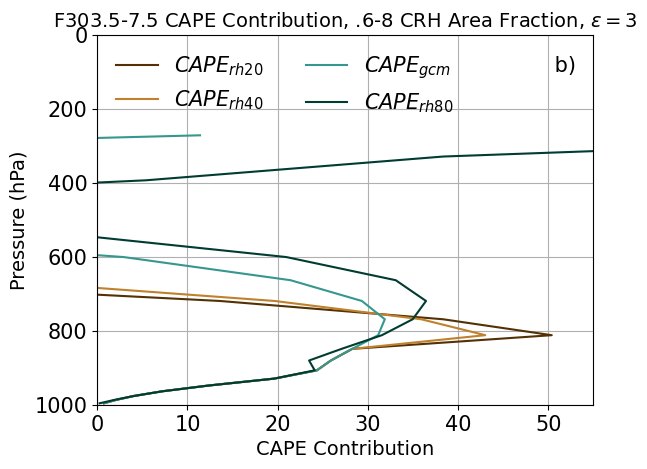

In [24]:
#subplots
path = '/home/disk/eos8/bdygert/code/compredo/'
casenumsc = ['f299rd2','f299rx1','f299rx3d2', 'f299rx2', 'f299rx3', 'f302rd2','fixedn1', 'f302rx3d2b',
             'fixedn1x2', 'f302rx3', 'f303rd2', 'f303r1', 'f303rx3d2','f303rx2','f303rx3',
             'f305rd2', 'fixedn1p3', 'f305rx3d2', 'f305rx2','f305rx3']
cn = len(casenumsc)
pfull = pfull.ravel()
fname='fig9b.pdf'
#vvar = 'crh'
#tlab = 'CRH (%)'
#vvar = 'crh'
#tlab = 'CRH (%)'
#vvar = 'CAPE3'
#tlab = 'CAPE to 400 hPa'
#vvar = 'CAPErh80u3'
#tlab = 'CAPE to 400 hPa (RH=80)'
#vvar = 'CAPErh40u3'
#tlab = 'CAPE to 400 hPa (RH=40 at 600 hPa)'
ev=3
#ev=4
dorh=0
if dorh:
    ev=4
vvar = 'CAPErh40maxu233'
#s='$RH_{max20}, p<$'
s='$RH_{max40}, p\leq$'
s1='$RH_{max20}, p\leq$'
s2='$RH_{max40}, p\leq$'
s3='$RH_{gcm}$'
s4='$RH_{80}$'

#llabs = [s+str(round(pfull[23])),s+str(round(pfull[21])),s+str(round(pfull[19])),s+str(round(pfull[18])),'CTL3','CTL2','CTL0','CAPEpy']
llabs = [s+str(round(pfull[24])),s+str(round(pfull[22])),s+str(round(pfull[20])),s+str(round(pfull[19])),'CTL3','CTL2','CTL0','CAPEpy']

#tlab = 'CAPE to 400 hPa (RH=40 Max at 600 hPa)'
xstr = 'CAPE Contribution'
tlab = 'Pressure (hPa)'
pv=15
sstx = 0
#vvar = 't_surf'
#tlab = 'SST Anomalies (K)'
dossts=0
indssts = np.array([1,1,1, 1, 1, 2,2, 2, 2, 2, 3,3,3, 3, 3, 4,4, 4, 4, 4])
indranges = np.array([1,2,3, 4, 5, 1,2, 3, 4, 5, 1, 2, 3,4,5, 1, 2, 3, 4,5])
ssts = ['299', '302', '303.5','305']
ranges = ['2.5','5','7.5','10','15']
pi = 3
pj = 3
j = 12
if ev==2:
    ttlab = newcasenum(casenumsc[j])+' CAPE Contribution, .6-8 CRH Area Fraction, $\epsilon=2$'
    #vvars = ['CAPErh40maxu232','CAPErh40maxu212','CAPErh40maxu192','CAPErh40maxu182','CAPE3','CAPE2','CAPE0','pyCAPE']
    vvars = ['CAPErh20maxu232','CAPErh20maxu212','CAPErh20maxu192','CAPErh20maxu182','CAPE2']
    llabs = [s+str(round(pfull[24])),s+str(round(pfull[22])),s+str(round(pfull[20])),s+str(round(pfull[19])),'CTL2']
    if dorh:
        vvars = ['rh20maxu23','rh20maxu21','rh20maxu19','rh20maxu18']
        ttlab = newcasenum(casenumsc[j])+' RH Profile, .6-8 CRH Area Fraction'

elif ev==3:
    s1='$CAPE_{rh20}$'
    s2='$CAPE_{rh40}$'
    s4='$CAPE_{rh80}$'
    #vvars = ['CAPErh20maxu233','CAPErh20maxu213','CAPErh20maxu193','CAPErh20maxu183','CAPE3']
    #vvars = ['CAPErh40maxu233','CAPErh40maxu213','CAPErh40maxu193','CAPErh40maxu183','CAPE3']
    #llabs = [s+str(round(pfull[24])),s+str(round(pfull[22])),s+str(round(pfull[20])),s+str(round(pfull[19])),'CTL3']
    vvars = ['CAPErh20maxu233','CAPErh40maxu233','CAPE3','CAPErh80minu3']
    llabs = [s1,s2,'$CAPE_{gcm}$',s4]
    ttlab = newcasenum(casenumsc[j])+' CAPE Contribution, .6-8 CRH Area Fraction, $\epsilon=3$'
    if dorh:
        vvars = ['rh40maxu23','rh40maxu21','rh40maxu19','rh40maxu18']
        ttlab = newcasenum(casenumsc[j])+' RH Profile, .6-8 CRH Area Fraction'
elif ev==4:
    vvars = ['rh20maxu23','rh40maxu23','rh','rh80minu']
    llabs = [s1+str(round(pfull[23])),s2+str(round(pfull[23])),s3,s4]
    ttlab = newcasenum(casenumsc[j])+' RH Profile, .6-8 CRH Area Fraction'
#colors = plt.cm.BrBG(np.linspace(0,1,4))

#llabs = [s+str(round(pfull[24])),s+str(round(pfull[22])),s+str(round(pfull[20])),s+str(round(pfull[19])),'CTL3','CTL2','CTL0','CAPEpy']

if dossts:
    colors = plt.cm.Reds(np.linspace(0,1,6))
    colors = colors[1:]
    sz1=4
    sz2=5
else:
    colors = plt.cm.bwr(np.linspace(0,1,4))
    sz1=5
    sz2=4
#colors = plt.cm.Reds(np.linspace(0,1,6))
#colors = colors[1:]
colors = plt.cm.BrBG(np.linspace(0,1,6))
colors = colors[[0,1,4,5]]

crhs = np.ones((20,4,5))
crhs[:] = np.nan
tsurfs = np.ones((20,4,5))
tsurfs[:] = np.nan
for v in range(0,len(vvars)):
    vvar = vvars[v]
    #for j in range(cn):
    casenum = casenumsc[j]
    flnm = path + casenum+vvar+'2dcrh.mat'    
    if os.path.isfile(flnm):
        print('isfile?')
        data = loadmat(flnm)
        stf = data['stf']
        pfull=data['pfull']
        alin=data['alin']
    elif vvar == 'pyCAPE':
        flnm = path + casenum+'temp2dcrh.mat'
        data = loadmat(flnm)
        temp0 = data['stf']
        temp0=np.mean(temp0[0:20,:,:],2)
        flnm = path + casenum+'rh2dcrh.mat'
        data = loadmat(flnm)
        rh0 = data['stf']
        rh0 = np.mean(rh0[0:20,:,:],2)/100
        pfull0=data['pfull']
        pfull0 = np.ravel(pfull0)
        stf = np.zeros(np.shape(temp0))
        stf[:] = np.nan
        alin = np.linspace(0,1,20)
        ptest = np.ravel(pfull0)*units.hPa
        ptest = ptest[15:]
        for t in range(0,20):  
            ttest = (temp0[t,15:]-273.15)* units.degC
            rhtest = rh0[t,15:]
            Td = dewpoint_from_relative_humidity(ttest, rhtest)
            csvnm = path + casenum + vvar + '2dcrh.mat'
            x,y = surface_based_cape_cin(np.flip(ptest), np.flip(ttest), np.flip(Td))
            stf[t,31] = x.magnitude
        savemat(csvnm,{'stf':stf,'alin':alin,'pfull':pfull0})
    inds = indssts[j]-1
    indr = indranges[j]-1   
    if 'CAPE' in vvar:
        stfp = np.nanmean(stf[12:16,:],0)
        stf = np.nansum(stf[:,15:],1)
        #print(np.shape(stf))
        #if np.shape(stf)[0]>20:
        #    stf=stf[0:20]
        #crhs[:,inds,indr] = stf
    elif vvar=='rh':
        stfp=np.nanmean(np.nanmean(stf[12:16,:,:],0),1)/100
    elif dorh:
        print('here')
        stfp = np.nanmean(stf[12:16,:],0)
    else:
        stf = np.mean(stf,2)
        crhs[:,inds,indr] = stf[:-1,0]
    #flnm = path + casenum+'t_surf'+'2dcrh.mat'    
    #if os.path.isfile(flnm):
    #    data = loadmat(flnm)
    #    stf = data['stf']
    #    pfull=data['pfull']
    #    alin=data['alin']
    #    stf = np.mean(stf,2)
    #tsurfs[:,inds,indr] = stf[:-1,0]
    #vals[pj] = np.nanmean(crhs[12:16,pj,pi])
    plt.plot(stfp,pfull.ravel(),color=colors[v],label=llabs[v])
plt.grid('true')
#plt.ylim((0,1000))
plt.ylim((0,1000))

if 'CAPE' in vvar:
    plt.xlim((0,55))
#else:
#    plt.ylim((15,85))

    #axs[pi].annotate(plabi, xy=(1, 0), xycoords='axes fraction', fontsize=12,
    #            horizontalalignment='right', verticalalignment='bottom')
plt.text(50, 100, ' b)', fontsize=15)#,horizontalalignment='left', verticalalignment='top')#, transform=plt.transAxes)
if dorh:
    plt.legend(llabs,loc = "best",facecolor='none',edgecolor=
          'none',ncol=2,fontsize=12,bbox_to_anchor=(0.48, -0.01, 0.2, 0.2))
else:
    plt.legend(llabs,loc = "upper left",facecolor='none',edgecolor=
              'none',ncol=2)
plt.gca().invert_yaxis()
#plt.title(tlab)
plt.xlabel(xstr,fontsize=14)
plt.ylabel(tlab,x=.15,fontsize=14)
plt.title(ttlab,fontsize=14)
plt.rcParams['font.size'] = 14
plt.savefig(fname, dpi=400,bbox_inches='tight')
plt.show()
#plt.contourf(np.ravel(alin), np.ravel(pfull), stf.T, cmap=scmap, extend='both')
#plt.colorbar()

In [26]:
cs=pickcases('15')
print(cs)

['f299rx3' 'f302rx3' 'f303rx3' 'f305rx3']


In [27]:
v='15'
casenums = np.array(['f299rd2','f299rx1','f299rx3d2', 'f299rx2', 'f299rx3', 'f302rd2','fixedn1', 'f302rx3d2b',
             'fixedn1x2', 'f302rx3', 'f303rd2', 'f303r1', 'f303rx3d2','f303rx2','f303rx3',
             'f305rd2', 'fixedn1p3', 'f305rx3d2', 'f305rx2','f305rx3'])
ssts = np.array(['299', '302', '303.5','305'])
indssts = np.array([1,1,1, 1, 1, 2,2, 2, 2, 2, 3,3,3, 3, 3, 4,4, 4, 4, 4])
indranges = np.array([1,2,3, 4, 5, 1,2, 3, 4, 5, 1, 2, 3,4,5, 1, 2, 3, 4,5])
ranges = np.array(['2.5','5','7.5','10','15'])
if v in ssts:
    ind = np.nonzero(ssts==v)[0][0]
    subcases = casenums[indssts==ind]
elif v in ranges:
    ind = np.nonzero(ranges==v)[0][0]
    subcases = casenums[indranges==ind]


0.631578947368421
0.8421052631578947
0.631578947368421
0.8421052631578947
0.631578947368421
0.8421052631578947
0.631578947368421
0.8421052631578947
0.631578947368421
0.8421052631578947


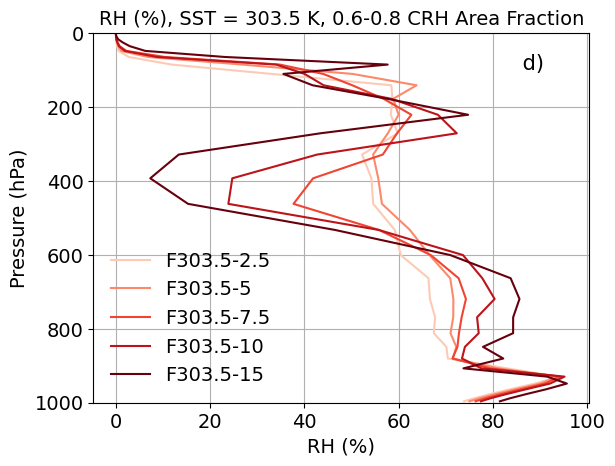

In [28]:
#subplots
path = '/home/disk/eos8/bdygert/code/compredo/'
casenumsc = ['f299rd2','f299rx1','f299rx3d2', 'f299rx2', 'f299rx3', 'f302rd2','fixedn1', 'f302rx3d2b',
             'fixedn1x2', 'f302rx3', 'f303rd2', 'f303r1', 'f303rx3d2','f303rx2','f303rx3',
             'f305rd2', 'fixedn1p3', 'f305rx3d2', 'f305rx2','f305rx3']
cn = len(casenumsc)
pfull = pfull.ravel()
#vvar = 'crh'
#tlab = 'CRH (%)'
#vvar = 'crh'
#tlab = 'CRH (%)'
#vvar = 'CAPE3'
#tlab = 'CAPE to 400 hPa'
#vvar = 'CAPErh80u3'
#tlab = 'CAPE to 400 hPa (RH=80)'
#vvar = 'CAPErh40u3'
#tlab = 'CAPE to 400 hPa (RH=40 at 600 hPa)'
ev=2
#use this set usually -> v
aa=12
ab=16
dotest=0
#just testing warmest
#aa = 16
#ab = 19

vvar = 'CAPErh40maxu233'
s='$RH_{max20}, p<$'
#llabs = [s+str(round(pfull[23])),s+str(round(pfull[21])),s+str(round(pfull[19])),s+str(round(pfull[18])),'CTL3','CTL2','CTL0','CAPEpy']
llabs = [s+str(round(pfull[24])),s+str(round(pfull[22])),s+str(round(pfull[20])),s+str(round(pfull[19])),'CTL3','CTL2','CTL0','CAPEpy']

#tlab = 'CAPE to 400 hPa (RH=40 Max at 600 hPa)'
xstr = 'CAPE Contribution'


tlab = 'Pressure (hPa)'
pv=15
sstx = 0
#vvar = 't_surf'
#tlab = 'SST Anomalies (K)'
#casenumsc=['f303rd2', 'f303r1', 'f303rx3d2','f303rx2','f303rx3']
sst='303.5'
casenumsc=pickcases(sst)
dossts=0
indssts = np.array([1,1,1, 1, 1, 2,2, 2, 2, 2, 3,3,3, 3, 3, 4,4, 4, 4, 4])
indranges = np.array([1,2,3, 4, 5, 1,2, 3, 4, 5, 1, 2, 3,4,5, 1, 2, 3, 4,5])
ssts = ['299', '302', '303.5','305']
ranges = ['2.5','5','7.5','10','15']
pi = 3
pj = 3
j = 12
#vvar = 'CAPE'+str(ev)
#vvar = 'vpp2db'
#xstr = 'VPP above Layer'
vvar='rh'
xstr='RH (%)'
#vvar = 'tdt_lw_clr'
#xstr = 'LW CLR (K/day)'
#vvar = 'tdt_lw'
#xstr = 'LW (K/day)'
#vvar='vpprhes'
#xstr='$RHe_{s}VPP^{-1}x10^5$'
#vvar = 'temp'
#xstr='T (K)'
#xstr = 'LW: CTS Approximation'
#vvar = 'lwcts1'
#vvar = 'rhes'
#xstr = '$RHe_{s}$'
#vvar='tdtconv'
#xstr='Q (K/day)'
alin = np.linspace(0,1,20)
astr = str(np.round(alin[aa],1))+'-'+str(np.round(alin[ab],1))+' CRH Area Fraction'
if ev==2 and 'CAPE' in vvar:
    #ttlab = 'CAPE Contribution, SST=303.5 K, .6-8 CRH Area Fraction, $\epsilon=2$'
    ttlab = 'CAPE Contribution, SST=303.5 K, '+astr+', $\epsilon=2$'
#    #vvars = ['CAPErh40maxu232','CAPErh40maxu212','CAPErh40maxu192','CAPErh40maxu182','CAPE3','CAPE2','CAPE0','pyCAPE']
#    vvars = ['CAPErh20maxu232','CAPErh20maxu212','CAPErh20maxu192','CAPErh20maxu182','CAPE2']
#    llabs = [s+str(round(pfull[24])),s+str(round(pfull[22])),s+str(round(pfull[20])),s+str(round(pfull[19])),'CTL2']
elif ev==3 and 'CAPE' in vvar:
#    vvars = ['CAPErh20maxu233','CAPErh20maxu213','CAPErh20maxu193','CAPErh20maxu183','CAPE3']
    #ttlab = 'CAPE Contribution, SST=303.5 K, .6-8 CRH Area Fraction, $\epsilon=3$'
    ttlab = 'CAPE Contribution, SST=303.5 K, '+astr+', $\epsilon=3$'
#    llabs = [s+str(round(pfull[24])),s+str(round(pfull[22])),s+str(round(pfull[20])),s+str(round(pfull[19])),'CTL3']
else:
    #ttlab = xstr+', SST = 303.5 K, .6-8 CRH Area Fraction'
    ttlab = xstr+', SST = 303.5 K, '+astr



#llabs = [s+str(round(pfull[24])),s+str(round(pfull[22])),s+str(round(pfull[20])),s+str(round(pfull[19])),'CTL3','CTL2','CTL0','CAPEpy']

if dossts:
    colors = plt.cm.Reds(np.linspace(0,1,6))
    colors = colors[1:]
    sz1=4
    sz2=5
else:
    colors = plt.cm.bwr(np.linspace(0,1,4))
    sz1=5
    sz2=4
colors = plt.cm.Reds(np.linspace(0,1,6))
colors = colors[1:]
crhs = np.ones((20,4,5))
crhs[:] = np.nan
tsurfs = np.ones((20,4,5))
tsurfs[:] = np.nan
#for v in range(0,len(vvars)):
for c in range(0,len(casenumsc)):
    #vvar = vvars[v]
    #for j in range(cn):
    casenum = casenumsc[c]
    flnm = path + casenum+vvar+'2dcrh.mat'    
    if os.path.isfile(flnm):
        data = loadmat(flnm)
        stf = data['stf']
        pfull=data['pfull']
        alin=data['alin']
    elif vvar == 'pyCAPE':
        flnm = path + casenum+'temp2dcrh.mat'
        data = loadmat(flnm)
        temp0 = data['stf']
        temp0=np.mean(temp0[0:20,:,:],2)
        flnm = path + casenum+'rh2dcrh.mat'
        data = loadmat(flnm)
        rh0 = data['stf']
        rh0 = np.mean(rh0[0:20,:,:],2)/100
        pfull0=data['pfull']
        pfull0 = np.ravel(pfull0)
        stf = np.zeros(np.shape(temp0))
        stf[:] = np.nan
        alin = np.linspace(0,1,20)
        ptest = np.ravel(pfull0)*units.hPa
        ptest = ptest[15:]
        for t in range(0,20):  
            ttest = (temp0[t,15:]-273.15)* units.degC
            rhtest = rh0[t,15:]
            Td = dewpoint_from_relative_humidity(ttest, rhtest)
            csvnm = path + casenum + vvar + '2dcrh.mat'
            x,y = surface_based_cape_cin(np.flip(ptest), np.flip(ttest), np.flip(Td))
            stf[t,31] = x.magnitude
        savemat(csvnm,{'stf':stf,'alin':alin,'pfull':pfull0})
    inds = indssts[j]-1
    indr = indranges[j]-1   
    if 'CAPE' in vvar:
        stfp = np.nanmean(stf[12:16,:],0)
        stf = np.nansum(stf[:,15:],1)
        #print(np.shape(stf))
        #if np.shape(stf)[0]>20:
        #    stf=stf[0:20]
        #crhs[:,inds,indr] = stf
    else:
        stf = np.mean(stf,2)
        #stfp = np.nanmean(stf[12:16,:],0)
        stfp = np.nanmean(stf[aa:ab,:],0)
        alin = np.linspace(0,1,20)
        print(alin[aa])
        print(alin[ab])
        crhs[:,inds,indr] = stf[:-1,0]
    flnm = path + casenum+'t_surf'+'2dcrh.mat'    
    if os.path.isfile(flnm):
        data = loadmat(flnm)
        stf = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        stf = np.mean(stf,2)
    tsurfs[:,inds,indr] = stf[:-1,0]
    #vals[pj] = np.nanmean(crhs[12:16,pj,pi])
    if 'tdt_lw' in vvar:
        stfp = stfp*3600*24
    elif 'vpprhes' in vvar:
        stfp=stfp*(10**5)
    plt.plot(stfp,pfull.ravel(),color=colors[c],label=newcasenum(casenum))
plt.grid('true')
plt.ylim((0,1000))
if 'CAPE' in vvar:
    print('here?')
    plt.xlim((0,150))
elif vvar=='vpp2db':
    plt.xlim(0,.75*10e6)
    plt.ylim((400,600))
elif 'lw' in vvar:
    plt.xlim((-5,1))
elif vvar == 'vpprhes':
    plt.xlim((0,10))
elif dotest:
    plt.xlim((0,8))
    
#else:
    #plt.ylim((15,85))

    #axs[pi].annotate(plabi, xy=(1, 0), xycoords='axes fraction', fontsize=12,
    #            horizontalalignment='right', verticalalignment='bottom')
lstr = "upper left"
cn=1
if vvar == 'rh' or vvar == 'temp':
    lstr = "lower left"
elif vvar =='tdt_lw':
    lstr = 'lower right'
    cn=1
#plt.legend(loc = 'lstr',facecolor='none',edgecolor=
#              'none',ncol=cn,fontsize=14)
plt.legend(loc = 'lower left',facecolor='none',edgecolor=
              'none',ncol=cn,fontsize=14)#,bbox_to_anchor=(.6, .3, 0.2, 0.2))
#xxx
plt.gca().invert_yaxis()
#plt.title(tlab)
plt.xlabel(xstr,fontsize=14)
#plt.text(-4.7, 100, ' a)', fontsize=15)
#plt.text(.5, 100, ' b)', fontsize=15)
#plt.text(300, 100, ' c)', fontsize=15)
plt.text(85, 100, ' d)', fontsize=15)

plt.ylabel(tlab,x=.15,fontsize=14)
plt.title(ttlab,fontsize=14)
plt.rcParams['font.size'] = 15
plt.savefig('fig7d.pdf', dpi=400,bbox_inches='tight')
plt.show()
#plt.contourf(np.ravel(alin), np.ravel(pfull), stf.T, cmap=scmap, extend='both')
#plt.colorbar()

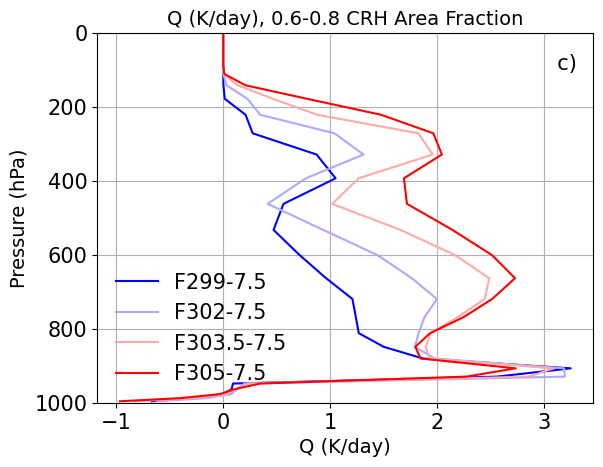

In [30]:
#subplots
path = '/home/disk/eos8/bdygert/code/compredo/'
casenumsc = ['f299rd2','f299rx1','f299rx3d2', 'f299rx2', 'f299rx3', 'f302rd2','fixedn1', 'f302rx3d2b',
             'fixedn1x2', 'f302rx3', 'f303rd2', 'f303r1', 'f303rx3d2','f303rx2','f303rx3',
             'f305rd2', 'fixedn1p3', 'f305rx3d2', 'f305rx2','f305rx3']
cn = len(casenumsc)
pfull = pfull.ravel()
#aa=0
#ab=4
aa=12
ab=16
dotest=0
#just testing warmest
#aa = 16
#ab = 19
#vvar = 'crh'
#tlab = 'CRH (%)'
#vvar = 'crh'
#tlab = 'CRH (%)'
#vvar = 'CAPE3'
#tlab = 'CAPE to 400 hPa'
#vvar = 'CAPErh80u3'
#tlab = 'CAPE to 400 hPa (RH=80)'
#vvar = 'CAPErh40u3'
#tlab = 'CAPE to 400 hPa (RH=40 at 600 hPa)'
ev=3
vvar = 'CAPErh40maxu233'
s='$RH_{max20}, p<$'
#llabs = [s+str(round(pfull[23])),s+str(round(pfull[21])),s+str(round(pfull[19])),s+str(round(pfull[18])),'CTL3','CTL2','CTL0','CAPEpy']
llabs = [s+str(round(pfull[24])),s+str(round(pfull[22])),s+str(round(pfull[20])),s+str(round(pfull[19])),'CTL3','CTL2','CTL0','CAPEpy']

#tlab = 'CAPE to 400 hPa (RH=40 Max at 600 hPa)'
xstr = 'CAPE Contribution'
tlab = 'Pressure (hPa)'
alin = np.linspace(0,1,20)
astr = str(np.round(alin[aa],1))+'-'+str(np.round(alin[ab],1))+' CRH Area Fraction'
pv=15
sstx = 0
#vvar = 't_surf'
#tlab = 'SST Anomalies (K)'
dossts=0
indssts = np.array([1,1,1, 1, 1, 2,2, 2, 2, 2, 3,3,3, 3, 3, 4,4, 4, 4, 4])
indranges = np.array([1,2,3, 4, 5, 1,2, 3, 4, 5, 1, 2, 3,4,5, 1, 2, 3, 4,5])
ssts = ['299', '302', '303.5','305']
ranges = ['2.5','5','7.5','10','15']
pi = 3
pj = 3
j = 12
vvar = 'CAPE'+str(ev)
vvar='tdtconv'
xstr='Q (K/day)'
#vvar = 'stf'
#xstr = 'STF'
#vvar='tdt_ls'
#xstr='Q RAS (K/day)'
#vvar='tdt_lw'
#xstr='LW (K/day)'
#vvar='vpp2db'
#xstr='vpp'
#vvar='rh'
#xstr='RH (%)'
casenumsc = ['f299rx3d2', 'f302rx3d2b','f303rx3d2','f305rx3d2']
if ev==2 and 'CAPE' in vvar:
    #ttlab = xstr+', Range = 7.5 K, .6-8 CRH Area Fraction, $\epsilon=2$'
    ttlab = 'CAPE Contribution, SST=303.5 K, '+astr+', $\epsilon=2$'
#    #vvars = ['CAPErh40maxu232','CAPErh40maxu212','CAPErh40maxu192','CAPErh40maxu182','CAPE3','CAPE2','CAPE0','pyCAPE']
#    vvars = ['CAPErh20maxu232','CAPErh20maxu212','CAPErh20maxu192','CAPErh20maxu182','CAPE2']
#    llabs = [s+str(round(pfull[24])),s+str(round(pfull[22])),s+str(round(pfull[20])),s+str(round(pfull[19])),'CTL2']
elif ev==3 and 'CAPE' in vvar:
    #ttlab = xstr+', Range = 7.5 K, .6-8 CRH Area Fraction, $\epsilon=3$'
    ttlab = 'CAPE Contribution '+astr+', $\epsilon=3$'
#    vvars = ['CAPErh20maxu233','CAPErh20maxu213','CAPErh20maxu193','CAPErh20maxu183','CAPE3']
#    llabs = [s+str(round(pfull[24])),s+str(round(pfull[22])),s+str(round(pfull[20])),s+str(round(pfull[19])),'CTL3']
else:
    #ttlab = xstr+', Range = 7.5 K, .6-8 CRH Area Fraction'
    ttlab = xstr+', '+astr



#llabs = [s+str(round(pfull[24])),s+str(round(pfull[22])),s+str(round(pfull[20])),s+str(round(pfull[19])),'CTL3','CTL2','CTL0','CAPEpy']

if dossts:
    colors = plt.cm.Reds(np.linspace(0,1,6))
    colors = colors[1:]
    sz1=4
    sz2=5
else:
    colors = plt.cm.bwr(np.linspace(0,1,4))
    sz1=5
    sz2=4
colors = plt.cm.bwr(np.linspace(0,1,4))
crhs = np.ones((20,4,5))
crhs[:] = np.nan
tsurfs = np.ones((20,4,5))
tsurfs[:] = np.nan
#for v in range(0,len(vvars)):
for c in range(0,len(casenumsc)):
    #vvar = vvars[v]
    #for j in range(cn):
    casenum = casenumsc[c]
    flnm = path + casenum+vvar+'2dcrh.mat'    
    if os.path.isfile(flnm):
        data = loadmat(flnm)
        stf = data['stf']
        pfull=data['pfull']
        alin=data['alin']
    elif vvar == 'pyCAPE':
        flnm = path + casenum+'temp2dcrh.mat'
        data = loadmat(flnm)
        temp0 = data['stf']
        temp0=np.mean(temp0[0:20,:,:],2)
        flnm = path + casenum+'rh2dcrh.mat'
        data = loadmat(flnm)
        rh0 = data['stf']
        rh0 = np.mean(rh0[0:20,:,:],2)/100
        pfull0=data['pfull']
        pfull0 = np.ravel(pfull0)
        stf = np.zeros(np.shape(temp0))
        stf[:] = np.nan
        alin = np.linspace(0,1,20)
        ptest = np.ravel(pfull0)*units.hPa
        ptest = ptest[15:]
        for t in range(0,20):  
            ttest = (temp0[t,15:]-273.15)* units.degC
            rhtest = rh0[t,15:]
            Td = dewpoint_from_relative_humidity(ttest, rhtest)
            csvnm = path + casenum + vvar + '2dcrh.mat'
            x,y = surface_based_cape_cin(np.flip(ptest), np.flip(ttest), np.flip(Td))
            stf[t,31] = x.magnitude
        savemat(csvnm,{'stf':stf,'alin':alin,'pfull':pfull0})
    inds = indssts[j]-1
    indr = indranges[j]-1   
    if 'CAPE' in vvar:
        #stfp = np.nanmean(stf[12:16,:],0)
        stfp = np.nanmean(stf[aa:ab,:],0)
        stf = np.nansum(stf[:,15:],1)
        #print(np.shape(stf))
        #if np.shape(stf)[0]>20:
        #    stf=stf[0:20]
        #crhs[:,inds,indr] = stf
    else:
        if vvar!='stf':
            stf = np.mean(stf,2)
            crhs[:,inds,indr] = stf[:-1,0]
        else:
            crhs[:,inds,indr] = stf[:,0]
        #stfp = np.nanmean(stf[12:16,:],0)
        stfp = np.nanmean(stf[aa:ab,:],0)
        alin = np.linspace(0,1,20)
    flnm = path + casenum+'t_surf'+'2dcrh.mat'    
    if os.path.isfile(flnm):
        data = loadmat(flnm)
        stf = data['stf']
        pfull=data['pfull']
        alin=data['alin']
        stf = np.mean(stf,2)
    tsurfs[:,inds,indr] = stf[:-1,0]
    #vals[pj] = np.nanmean(crhs[12:16,pj,pi])
    if vvar=='tdt_lw':
        stfp=stfp*24*3600
    plt.plot(stfp,pfull.ravel(),color=colors[c],label=newcasenum(casenum))
plt.grid('true')
plt.ylim((0,1000))
if 'CAPE' in vvar:
    plt.xlim((0,55))
elif vvar=='tdt_lw':
    plt.xlim((-3,0))
elif dotest:
    plt.xlim((0,8))

    #axs[pi].annotate(plabi, xy=(1, 0), xycoords='axes fraction', fontsize=12,
    #            horizontalalignment='right', verticalalignment='bottom')
    
#plt.legend(loc = "upper left",facecolor='none',edgecolor='none',ncol=2)
plt.legend(loc = "lower left",facecolor='none',edgecolor='none',ncol=1)#,fontsize=12)

plt.gca().invert_yaxis()
#plt.title(tlab)
plt.xlabel(xstr,fontsize=14)
plt.ylabel(tlab,x=.15,fontsize=14)
plt.title(ttlab,fontsize=14)
#plt.text(50, 100, ' d)',fontsize=15)#,ha='right', va='top')
plt.text(3, 100, '  c)',fontsize=15)#,ha='right', va='top')
plt.rcParams['font.size'] = 15
plt.savefig('fig9c.pdf', dpi=400,bbox_inches='tight')
plt.show()